# Part IV: Modelling

Five forecasters, split across two architectures:

| Model | Type | Fitted |
|---|---|---|
| LightGBM | global ML | one model across all series |
| XGBoost | global ML | one model across all series |
| Prophet | local | one model per series, with regressors |
| ARIMA | local | one model per series, univariate |
| SARIMA | local | one model per series, weekly seasonality |

The global/local split is the interesting axis. A global model borrows strength
across series; a local model sees only its own history but adapts fully to it.
Which wins depends on series volume and volatility, so the comparison is segmented
rather than reported as a single number.

## Basic settings

In [153]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [154]:
import json
import os
import pickle
import sys
import time
import warnings

import lightgbm as lgbm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

SEED = 2025
np.random.seed(SEED)

In [155]:
DATA_DIR = "../data"
MODELS_DIR = "../models"
FIGURES_DIR = "../figures"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

SALES_DATA_PATH = os.path.join(DATA_DIR, "feature_engineered_data_69_features.parquet")

# Local models fit one model per series. 360 series x 3 local models is slow, so
# a stratified subsample is used for development. Set to None for the full run.
N_LOCAL_SERIES = 24

## Load data

In [156]:
df_features = pd.read_parquet(SALES_DATA_PATH)
print(f"{len(df_features):,} rows x {df_features.shape[1]} cols")
print(f"date range : {df_features['date'].min().date()} to {df_features['date'].max().date()}")
print(f"train rows : {int((~df_features['is_test']).sum()):,}")
print(f"test rows  : {int(df_features['is_test'].sum()):,}")
print(f"series     : {df_features['store_item'].nunique()}")

384,480 rows x 69 cols
date range : 2023-01-29 to 2025-12-31
train rows : 351,360
test rows  : 33,120
series     : 360


## Evaluation metrics

`MASE` matters most here. Item volumes span a wide range (bread around 48 units a
day, firelighters around 4), so MAE and RMSE are dominated by the high-volume
series. MASE scales each series by its own naive-forecast error, which makes the
average across series meaningful.

In [157]:
def wape(y_true, y_pred):
    """Weighted absolute percentage error."""
    return 100 * np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


def mase(y_true, y_pred, y_train, season=1):
    """Mean absolute scaled error, scaled by the in-sample naive forecast."""
    naive = np.mean(np.abs(np.diff(y_train, n=season)))
    if not np.isfinite(naive) or naive <= 0:
        return np.nan
    return np.mean(np.abs(y_true - y_pred)) / naive


def score(y_true, y_pred, y_train=None, label=""):
    out = {
        "model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "WAPE": wape(y_true, y_pred),
    }
    if y_train is not None:
        out["MASE"] = mase(y_true, y_pred, y_train)
    return out

## Global models: feature matrix

Columns dropped and why:

- `date`, `is_test` - bookkeeping
- `store_item` - a string key, already encoded by `store_id` and `item_id`
- `promo_id` - an arbitrary campaign identifier. It carries no generalisable signal
  and lets the model memorise individual promotions.
- `store_name`, `item_name` - redundant with the IDs

Category-dtype columns are kept. LightGBM and XGBoost both consume them natively,
which avoids fitting a one-hot encoder on train and test together.

In [158]:
DROP_COLS = ["date", "is_test", "store_item", "promo_id", "store_name", "item_name"]
DROP_WEATHER_COLS = ["temperature", "humidity", "season", "temp_norm", "temp_anomally", "is_humid", "temp_category", "humidity_level", "humidity","heat_excess", "cold_excess"]
DROP_CALENDAR_COLUMNS = ["year", "month", "day", "day_of_week", "is_weekend", "quarter", "week_of_year", "day_of_year", "month_sin", "month_cos", "dow_sin", "dow_cos", "days_to_christmas", "is_christmas_date", "is_pre_holiday"]
DROP_PROMOTION_COLUMNS = ["log_price_ratio", "is_deep_discount", "rival_discount_pct", "discount_pct"]
TARGET = "sales"

feature_cols = [c for c in df_features.columns if c not in DROP_COLS +  [TARGET]]

feature_cols_NO_WEATHER = [c for c in df_features.columns if c not in DROP_COLS + DROP_WEATHER_COLS + [TARGET]]
feature_cols_NO_CALENDAR = [c for c in df_features.columns if c not in DROP_COLS + DROP_CALENDAR_COLUMNS + [TARGET]]
feature_cols_NO_PROMOTION = [c for c in df_features.columns if c not in DROP_COLS + DROP_PROMOTION_COLUMNS + [TARGET]]

train_mask = ~df_features["is_test"]
X_train = df_features.loc[train_mask, feature_cols]
X_train_NO_WEATHER = df_features.loc[train_mask, feature_cols_NO_WEATHER]
X_train_NO_CALENDAR = df_features.loc[train_mask, feature_cols_NO_CALENDAR]
X_train_NO_PROMOTION = df_features.loc[train_mask, feature_cols_NO_PROMOTION]
y_train = df_features.loc[train_mask, TARGET]
X_test = df_features.loc[~train_mask, feature_cols]
X_test_NO_WEATHER = df_features.loc[~train_mask, feature_cols_NO_WEATHER]
X_test_NO_CALENDAR = df_features.loc[~train_mask, feature_cols_NO_CALENDAR]
X_test_NO_PROMOTION = df_features.loc[~train_mask, feature_cols_NO_PROMOTION]
y_test = df_features.loc[~train_mask, TARGET]

cat_features = [c for c in feature_cols if str(X_train[c].dtype) == "category"]
cat_features_NO_WEATHER = [c for c in feature_cols_NO_WEATHER if str(X_train[c].dtype) == "category"]
cat_features_NO_CALENDAR = [c for c in feature_cols_NO_CALENDAR if str(X_train[c].dtype) == "category"]
cat_features_NO_PROMOTION = [c for c in feature_cols_NO_PROMOTION if str(X_train[c].dtype) == "category"]
print(f"{len(feature_cols)} features, {len(cat_features)} categorical")
print(f"train {X_train.shape}  test {X_test.shape}")

62 features, 7 categorical
train (351360, 62)  test (33120, 62)


### A validation split carved out of training

Early stopping needs a held-out set. Using the test set for it - as
`eval_set=[(X_test, y_test)]` would - selects the number of trees on the data the
model is then scored on, which inflates the result.

The last 28 days before the cutoff serve as validation instead.

In [159]:
cutoff = df_features.loc[~train_mask, "date"].min()
val_start = cutoff - pd.Timedelta(days=28)

fit_mask = train_mask & (df_features["date"] < val_start)
val_mask = train_mask & (df_features["date"] >= val_start)

X_fit, y_fit = df_features.loc[fit_mask, feature_cols], df_features.loc[fit_mask, TARGET]
X_val, y_val = df_features.loc[val_mask, feature_cols], df_features.loc[val_mask, TARGET]

X_fit_NO_WEATHER = df_features.loc[fit_mask, feature_cols_NO_WEATHER]
X_val_NO_WEATHER = df_features.loc[val_mask, feature_cols_NO_WEATHER]

X_fit_NO_CALENDAR = df_features.loc[fit_mask, feature_cols_NO_CALENDAR]
X_val_NO_CALENDAR = df_features.loc[val_mask, feature_cols_NO_CALENDAR]

X_fit_NO_PROMOTION = df_features.loc[fit_mask, feature_cols_NO_PROMOTION]
X_val_NO_PROMOTION = df_features.loc[val_mask, feature_cols_NO_PROMOTION]

print(f"fit  : {len(X_fit):,} rows (to {df_features.loc[fit_mask,'date'].max().date()})")
print(f"val  : {len(X_val):,} rows ({val_start.date()} to {(cutoff - pd.Timedelta(days=1)).date()})")
print(f"test : {len(X_test):,} rows (from {cutoff.date()})")

fit  : 341,280 rows (to 2025-09-02)
val  : 10,080 rows (2025-09-03 to 2025-09-30)
test : 33,120 rows (from 2025-10-01)


## Model 1: LightGBM

In [160]:
lgbm_params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "num_leaves": 63,
    "learning_rate": 0.05,
    "feature_fraction": 0.85,
    "bagging_fraction": 0.85,
    "bagging_freq": 1,
    "min_child_samples": 40,
    "n_estimators": 2000,
    "random_state": SEED,
    "n_jobs": -1,
    "verbose": -1,
}

t0 = time.time()
lgbm_model = lgbm.LGBMRegressor(**lgbm_params)
lgbm_model.fit(
    X_fit, y_fit,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[lgbm.early_stopping(100, verbose=False), lgbm.log_evaluation(0)],
    categorical_feature=cat_features,
)

lgbm_model_NO_WEATHER = lgbm.LGBMRegressor(**lgbm_params)
lgbm_model_NO_WEATHER.fit(
    X_fit_NO_WEATHER, y_fit,
    eval_set=[(X_val_NO_WEATHER, y_val)],
    eval_metric="rmse",
    callbacks=[lgbm.early_stopping(100, verbose=False), lgbm.log_evaluation(0)],
    categorical_feature=cat_features_NO_WEATHER,
)
lgbm_model_NO_CALENDAR = lgbm.LGBMRegressor(**lgbm_params)
lgbm_model_NO_CALENDAR.fit(
    X_fit_NO_CALENDAR, y_fit,
    eval_set=[(X_val_NO_CALENDAR, y_val)],
    eval_metric="rmse",
    callbacks=[lgbm.early_stopping(100, verbose=False), lgbm.log_evaluation(0)],
    categorical_feature=cat_features_NO_CALENDAR,
)
lgbm_model_NO_PROMOTION = lgbm.LGBMRegressor(**lgbm_params)
lgbm_model_NO_PROMOTION.fit(
    X_fit_NO_PROMOTION, y_fit,
    eval_set=[(X_val_NO_PROMOTION, y_val)],
    eval_metric="rmse",
    callbacks=[lgbm.early_stopping(100, verbose=False), lgbm.log_evaluation(0)],
    categorical_feature=cat_features_NO_PROMOTION,
)
lgbm_time = time.time() - t0

pred_lgbm = lgbm_model.predict(X_test)
pred_lgbm_NO_WEATHER = lgbm_model_NO_WEATHER.predict(X_test_NO_WEATHER)
pred_lgbm_NO_CALENDAR = lgbm_model_NO_CALENDAR.predict(X_test_NO_CALENDAR)
pred_lgbm_NO_PROMOTION = lgbm_model_NO_PROMOTION.predict(X_test_NO_PROMOTION)
print(f"best iteration: {lgbm_model.best_iteration_}   fit time: {lgbm_time:.1f}s")
display(pd.DataFrame([score(y_test, pred_lgbm, y_train, "LightGBM")]).round(4))
display(pd.DataFrame([score(y_test, pred_lgbm_NO_WEATHER, y_train, "LightGBM No Weather Data")]).round(4))
display(pd.DataFrame([score(y_test, pred_lgbm_NO_CALENDAR, y_train, "LightGBM No Calendar Data")]).round(4))
display(pd.DataFrame([score(y_test, pred_lgbm_NO_PROMOTION, y_train, "LightGBM No Promotion Data")]).round(4))

best iteration: 416   fit time: 17.5s


,model,MAE,RMSE,WAPE,MASE
0,LightGBM,5.3012,8.0677,24.7095,0.7521


,model,MAE,RMSE,WAPE,MASE
0,LightGBM No Weather Data,5.2866,8.0428,24.6416,0.75


,model,MAE,RMSE,WAPE,MASE
0,LightGBM No Calendar Data,5.5612,8.3634,25.9214,0.789


,model,MAE,RMSE,WAPE,MASE
0,LightGBM No Promotion Data,5.2688,8.0654,24.5584,0.7475


## Model 2: XGBoost

In [161]:
xgb_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_estimators": 2000,
    "learning_rate": 0.05,
    "max_depth": 8,
    "min_child_weight": 10,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "tree_method": "hist",
    "enable_categorical": True,
    "early_stopping_rounds": 100,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": 0,
}

t0 = time.time()
xgb_model = xgb.XGBRegressor(**xgb_params)
xgb_model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

xgb_model_NO_WEATHER = xgb.XGBRegressor(**xgb_params)
xgb_model_NO_WEATHER.fit(X_fit_NO_WEATHER, y_fit, eval_set=[(X_val_NO_WEATHER, y_val)], verbose=False)

xgb_model_NO_CALENDAR = xgb.XGBRegressor(**xgb_params)
xgb_model_NO_CALENDAR.fit(X_fit_NO_CALENDAR, y_fit, eval_set=[(X_val_NO_CALENDAR, y_val)], verbose=False)

xgb_model_NO_PROMOTION = xgb.XGBRegressor(**xgb_params)
xgb_model_NO_PROMOTION.fit(X_fit_NO_PROMOTION, y_fit, eval_set=[(X_val_NO_PROMOTION, y_val)], verbose=False)
xgb_time = time.time() - t0

pred_xgb = xgb_model.predict(X_test)
pred_xgb_NO_WEATHER = xgb_model_NO_WEATHER.predict(X_test_NO_WEATHER)
pred_xgb_NO_CALENDAR = xgb_model_NO_CALENDAR.predict(X_test_NO_CALENDAR)
pred_xgb_NO_PROMOTION = xgb_model_NO_PROMOTION.predict(X_test_NO_PROMOTION)
print(f"best iteration: {xgb_model.best_iteration}   fit time: {xgb_time:.1f}s")
display(pd.DataFrame([score(y_test, pred_xgb, y_train, "XGBoost")]).round(4))
display(pd.DataFrame([score(y_test, pred_xgb_NO_WEATHER, y_train, "XGBoost No Weather Data")]).round(4))
display(pd.DataFrame([score(y_test, pred_xgb_NO_CALENDAR, y_train, "XGBoost No Calendar Data")]).round(4))
display(pd.DataFrame([score(y_test, pred_xgb_NO_PROMOTION, y_train, "XGBoost No Promotion Data")]).round(4))

best iteration: 309   fit time: 29.6s


,model,MAE,RMSE,WAPE,MASE
0,XGBoost,5.3453,8.1272,24.9153,0.7583


,model,MAE,RMSE,WAPE,MASE
0,XGBoost No Weather Data,5.3402,8.1194,24.8913,0.7576


,model,MAE,RMSE,WAPE,MASE
0,XGBoost No Calendar Data,5.5692,8.3711,25.9589,0.7901


,model,MAE,RMSE,WAPE,MASE
0,XGBoost No Promotion Data,5.3469,8.1294,24.9228,0.7586


## Local models

Prophet, ARIMA and SARIMA fit one model per series. For a like-for-like comparison
every model must be scored on the **same series** over the **same test window**, so
a stratified sample is drawn across the volume range and all five models are then
compared on exactly those series.

In [162]:
series_vol = (
    df_features[train_mask].groupby("store_item")["sales"].mean().sort_values()
)

if N_LOCAL_SERIES is None:
    local_series = series_vol.index.tolist()
else:
    # Even spread across the volume range rather than a random draw, so low and
    # high volume series are both represented.
    idx = np.linspace(0, len(series_vol) - 1, N_LOCAL_SERIES).astype(int)
    local_series = series_vol.index[idx].tolist()

print(f"{len(local_series)} series selected for local models")
print(f"volume range: {series_vol[local_series].min():.1f} to {series_vol[local_series].max():.1f} units/day")

24 series selected for local models
volume range: 3.7 to 53.4 units/day


In [163]:
# Long panel used by all three local models.
panel = df_features[
    ["date", "store_item", "sales", "is_test", "is_weekend",
     "is_public_holiday", "is_school_holiday", "temp_anomaly",
     "humidity", "is_promotion", "discount_pct"]
].copy()
panel = panel[panel["store_item"].isin(local_series)].sort_values(["store_item", "date"])

print(f"{len(panel):,} rows across {panel['store_item'].nunique()} series")
display(panel.head(3))

25,632 rows across 24 series


,date,store_item,sales,is_test,is_weekend,is_public_holiday,is_school_holiday,temp_anomaly,humidity,is_promotion,discount_pct
348168,2023-01-29,11_27,11.0,False,1,0,0,4.66,38.4,1,20.1
348169,2023-01-30,11_27,6.0,False,0,0,0,1.86,53.5,1,19.9
348170,2023-01-31,11_27,5.0,False,0,0,0,3.96,43.7,1,19.9


## Model 3: Prophet

Prophet is given the external regressors rather than run univariate, which is the
fair comparison against the global models: they see promotions and weather, so
Prophet should too.

In [164]:
PROPHET_REGRESSORS = ["is_weekend", "is_public_holiday", "is_school_holiday",
                      "temp_anomaly", "is_promotion", "discount_pct"]


def run_prophet(panel, series_ids, regressors=PROPHET_REGRESSORS):
    """Fit one Prophet model per series and forecast the test window."""
    rows = []
    t0 = time.time()
    for i, sid in enumerate(series_ids, 1):
        g = panel[panel["store_item"] == sid]
        tr = g[~g["is_test"]].rename(columns={"date": "ds", "sales": "y"})
        te = g[g["is_test"]].rename(columns={"date": "ds", "sales": "y"})
        if len(tr) < 60 or len(te) == 0:
            continue

        m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                    daily_seasonality=False, seasonality_mode="multiplicative",
                    interval_width=0.8)
        for r in regressors:
            m.add_regressor(r)
        m.fit(tr[["ds", "y"] + regressors])

        fc = m.predict(te[["ds"] + regressors])
        rows.append(pd.DataFrame({
            "store_item": sid,
            "date": te["ds"].values,
            "actual": te["y"].values,
            "pred_Prophet": np.maximum(fc["yhat"].values, 0),
        }))
        if i % 8 == 0:
            print(f"  {i}/{len(series_ids)} series ({time.time()-t0:.0f}s)")

    print(f"Prophet done in {time.time()-t0:.0f}s")
    return pd.concat(rows, ignore_index=True)


prophet_preds = run_prophet(panel, local_series)
display(prophet_preds.head())

19:30:47 - cmdstanpy - INFO - Chain [1] start processing
19:30:47 - cmdstanpy - INFO - Chain [1] done processing
19:30:47 - cmdstanpy - INFO - Chain [1] start processing
19:30:47 - cmdstanpy - INFO - Chain [1] done processing
19:30:47 - cmdstanpy - INFO - Chain [1] start processing
19:30:47 - cmdstanpy - INFO - Chain [1] done processing
19:30:47 - cmdstanpy - INFO - Chain [1] start processing
19:30:47 - cmdstanpy - INFO - Chain [1] done processing
19:30:48 - cmdstanpy - INFO - Chain [1] start processing
19:30:48 - cmdstanpy - INFO - Chain [1] done processing
19:30:48 - cmdstanpy - INFO - Chain [1] start processing
19:30:48 - cmdstanpy - INFO - Chain [1] done processing
19:30:48 - cmdstanpy - INFO - Chain [1] start processing
19:30:48 - cmdstanpy - INFO - Chain [1] done processing
19:30:48 - cmdstanpy - INFO - Chain [1] start processing
19:30:48 - cmdstanpy - INFO - Chain [1] done processing
19:30:49 - cmdstanpy - INFO - Chain [1] start processing


  8/24 series (2s)


19:30:49 - cmdstanpy - INFO - Chain [1] done processing
19:30:49 - cmdstanpy - INFO - Chain [1] start processing
19:30:49 - cmdstanpy - INFO - Chain [1] done processing
19:30:49 - cmdstanpy - INFO - Chain [1] start processing
19:30:49 - cmdstanpy - INFO - Chain [1] done processing
19:30:49 - cmdstanpy - INFO - Chain [1] start processing
19:30:49 - cmdstanpy - INFO - Chain [1] done processing
19:30:50 - cmdstanpy - INFO - Chain [1] start processing
19:30:50 - cmdstanpy - INFO - Chain [1] done processing
19:30:50 - cmdstanpy - INFO - Chain [1] start processing
19:30:50 - cmdstanpy - INFO - Chain [1] done processing
19:30:50 - cmdstanpy - INFO - Chain [1] start processing
19:30:50 - cmdstanpy - INFO - Chain [1] done processing
19:30:50 - cmdstanpy - INFO - Chain [1] start processing
19:30:50 - cmdstanpy - INFO - Chain [1] done processing
19:30:50 - cmdstanpy - INFO - Chain [1] start processing


  16/24 series (4s)


19:30:51 - cmdstanpy - INFO - Chain [1] done processing
19:30:51 - cmdstanpy - INFO - Chain [1] start processing
19:30:51 - cmdstanpy - INFO - Chain [1] done processing
19:30:51 - cmdstanpy - INFO - Chain [1] start processing
19:30:51 - cmdstanpy - INFO - Chain [1] done processing
19:30:51 - cmdstanpy - INFO - Chain [1] start processing
19:30:51 - cmdstanpy - INFO - Chain [1] done processing
19:30:51 - cmdstanpy - INFO - Chain [1] start processing
19:30:51 - cmdstanpy - INFO - Chain [1] done processing
19:30:52 - cmdstanpy - INFO - Chain [1] start processing
19:30:52 - cmdstanpy - INFO - Chain [1] done processing
19:30:52 - cmdstanpy - INFO - Chain [1] start processing
19:30:52 - cmdstanpy - INFO - Chain [1] done processing
19:30:52 - cmdstanpy - INFO - Chain [1] start processing
19:30:52 - cmdstanpy - INFO - Chain [1] done processing


  24/24 series (6s)
Prophet done in 6s


,store_item,date,actual,pred_Prophet
0,12_30,2025-10-01,3.0,3.350911
1,12_30,2025-10-02,1.0,3.842491
2,12_30,2025-10-03,6.0,4.105082
3,12_30,2025-10-04,2.0,4.312512
4,12_30,2025-10-05,2.0,3.915274


## Models 4 and 5: ARIMA and SARIMA

Both are fitted with `statsmodels` SARIMAX using fixed orders rather than a full
`auto_arima` search, which would take hours across hundreds of series. ARIMA uses
(1,1,1); SARIMA adds a weekly seasonal term (1,0,1,7), since retail demand is
strongly day-of-week driven.

These two are **univariate** - no promotions, no weather. That is the honest
comparison: it is what these models are, and the gap against the regressor-aware
models is itself a result about how much the external factors contribute.

In [165]:
def run_sarimax(panel, series_ids, order, seasonal_order, label):
    """Fit one SARIMAX per series and forecast the test window."""
    rows, failures = [], 0
    t0 = time.time()
    for i, sid in enumerate(series_ids, 1):
        g = panel[panel["store_item"] == sid]
        tr = g[~g["is_test"]]
        te = g[g["is_test"]]
        if len(tr) < 60 or len(te) == 0:
            continue
        try:
            model = SARIMAX(
                tr["sales"].values,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fit = model.fit(disp=False, maxiter=100)
            fc = fit.forecast(steps=len(te))
        except Exception:
            failures += 1
            fc = np.repeat(tr["sales"].tail(7).mean(), len(te))  # naive fallback

        rows.append(pd.DataFrame({
            "store_item": sid,
            "date": te["date"].values,
            "actual": te["sales"].values,
            f"pred_{label}": np.maximum(np.asarray(fc, dtype=float), 0),
        }))
        if i % 8 == 0:
            print(f"  {i}/{len(series_ids)} series ({time.time()-t0:.0f}s)")

    print(f"{label} done in {time.time()-t0:.0f}s, {failures} fallbacks")
    return pd.concat(rows, ignore_index=True)


arima_preds = run_sarimax(panel, local_series, (1, 1, 1), (0, 0, 0, 0), "ARIMA")

  8/24 series (0s)
  16/24 series (1s)
  24/24 series (1s)
ARIMA done in 1s, 0 fallbacks


In [166]:
sarima_preds = run_sarimax(panel, local_series, (1, 1, 1), (1, 0, 1, 7), "SARIMA")

  8/24 series (2s)
  16/24 series (5s)
  24/24 series (8s)
SARIMA done in 8s, 0 fallbacks


## Head-to-head comparison

All five models on the same series and the same test window. The global models are
scored twice: on the full test set, and restricted to the sampled series so the
comparison against the local models is like-for-like.

In [167]:
# Global predictions attached back to their keys.
global_preds = df_features.loc[~train_mask, ["date", "store_item", "sales"]].copy()
global_preds["pred_LightGBM"] = pred_lgbm
global_preds["pred_XGBoost"] = pred_xgb

comparison = (
    global_preds[global_preds["store_item"].isin(local_series)]
    .rename(columns={"sales": "actual"})
    .merge(prophet_preds, on=["store_item", "date", "actual"], how="inner")
    .merge(arima_preds, on=["store_item", "date", "actual"], how="inner")
    .merge(sarima_preds, on=["store_item", "date", "actual"], how="inner")
)
print(f"{len(comparison):,} rows across {comparison['store_item'].nunique()} series")

train_by_series = df_features[train_mask].groupby("store_item")["sales"]

rows = []
for label in ["LightGBM", "XGBoost", "Prophet", "ARIMA", "SARIMA"]:
    col = f"pred_{label}"
    per_series = []
    for sid, g in comparison.groupby("store_item"):
        per_series.append(
            mase(g["actual"].values, g[col].values, train_by_series.get_group(sid).values)
        )
    rows.append({
        "model": label,
        "MAE": mean_absolute_error(comparison["actual"], comparison[col]),
        "RMSE": np.sqrt(mean_squared_error(comparison["actual"], comparison[col])),
        "WAPE": wape(comparison["actual"].values, comparison[col].values),
        "MASE": np.nanmean(per_series),
    })

results = pd.DataFrame(rows).sort_values("MASE").reset_index(drop=True)
display(results.round(4))

2,208 rows across 24 series


,model,MAE,RMSE,WAPE,MASE
0,LightGBM,5.2760,7.9332,23.4694,0.7244
1,XGBoost,5.3869,8.0662,23.9627,0.7386
2,Prophet,5.7829,9.0010,25.7242,0.7757
3,ARIMA,8.5920,12.1267,38.2202,1.1760
4,SARIMA,9.0500,12.7769,40.2578,1.2415


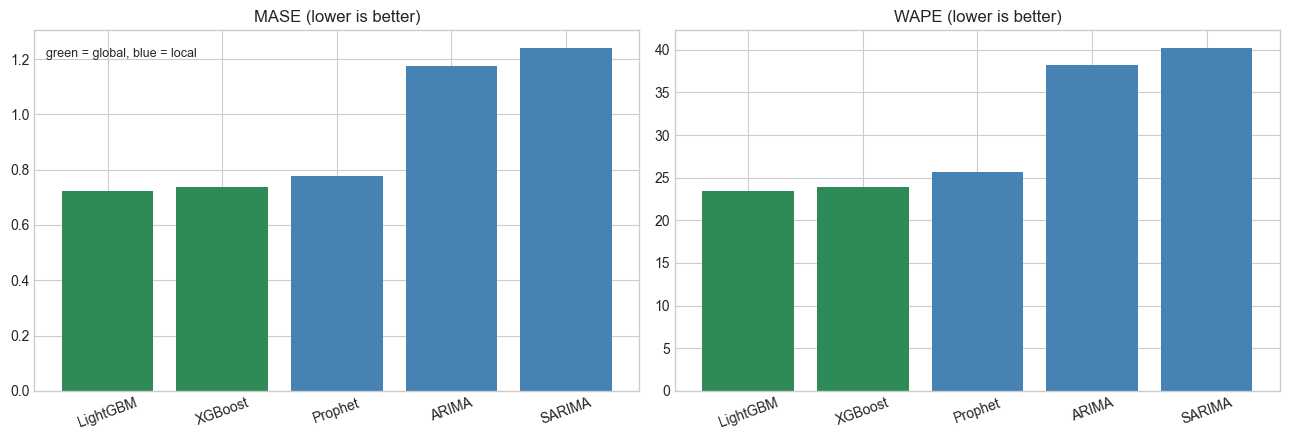

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric in zip(axes, ["MASE", "WAPE"]):
    r = results.sort_values(metric)
    colors = ["seagreen" if m in ("LightGBM", "XGBoost") else "steelblue"
              for m in r["model"]]
    ax.bar(r["model"], r[metric], color=colors)
    ax.set_title(f"{metric} (lower is better)")
    ax.tick_params(axis="x", rotation=20)
axes[0].text(0.02, 0.95, "green = global, blue = local",
             transform=axes[0].transAxes, fontsize=9, va="top")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_comparison.png"), dpi=120)
plt.show()

### Is the difference statistically meaningful?

A gap in MASE is not evidence on its own. Diebold-Mariano tests whether two error
series differ by more than sampling noise. Any later claim that two models are
"equivalent" needs this test behind it.

In [169]:
from scipy import stats


def diebold_mariano(e1, e2):
    d = e1 ** 2 - e2 ** 2
    n = len(d)
    var = np.var(d, ddof=0) / n
    if var <= 0:
        return np.nan, np.nan
    stat = d.mean() / np.sqrt(var)
    return float(stat), float(2 * (1 - stats.norm.cdf(abs(stat))))


models = ["LightGBM", "XGBoost", "Prophet", "ARIMA", "SARIMA"]
errors = {m: (comparison["actual"] - comparison[f"pred_{m}"]).values for m in models}

dm_rows = []
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        s, p = diebold_mariano(errors[models[i]], errors[models[j]])
        dm_rows.append({
            "model_a": models[i], "model_b": models[j],
            "dm_stat": s, "p_value": p,
            "equivalent": bool(p > 0.05) if np.isfinite(p) else None,
        })
display(pd.DataFrame(dm_rows).round(4))

,model_a,model_b,dm_stat,p_value,equivalent
0,LightGBM,XGBoost,-2.1861,0.0288,False
1,LightGBM,Prophet,-4.9442,0.0000,False
2,LightGBM,ARIMA,-14.4636,0.0000,False
3,LightGBM,SARIMA,-15.9773,0.0000,False
4,XGBoost,Prophet,-4.4838,0.0000,False
5,XGBoost,ARIMA,-13.9592,0.0000,False
6,XGBoost,SARIMA,-15.5329,0.0000,False
7,Prophet,ARIMA,-11.2182,0.0000,False
8,Prophet,SARIMA,-13.0860,0.0000,False
9,ARIMA,SARIMA,-7.5493,0.0000,False


### Segmented comparison

The aggregate winner is the least interesting part. Global models borrow strength
across series, which helps most where a single series has too little signal to fit
on its own. Splitting by volume shows where each family earns its keep.

volume_band,high volume,low volume,mid volume
model,,,
ARIMA,1.187,0.965,1.376
LightGBM,0.742,0.696,0.735
Prophet,0.843,0.727,0.757
SARIMA,1.187,0.957,1.580
XGBoost,0.756,0.712,0.747


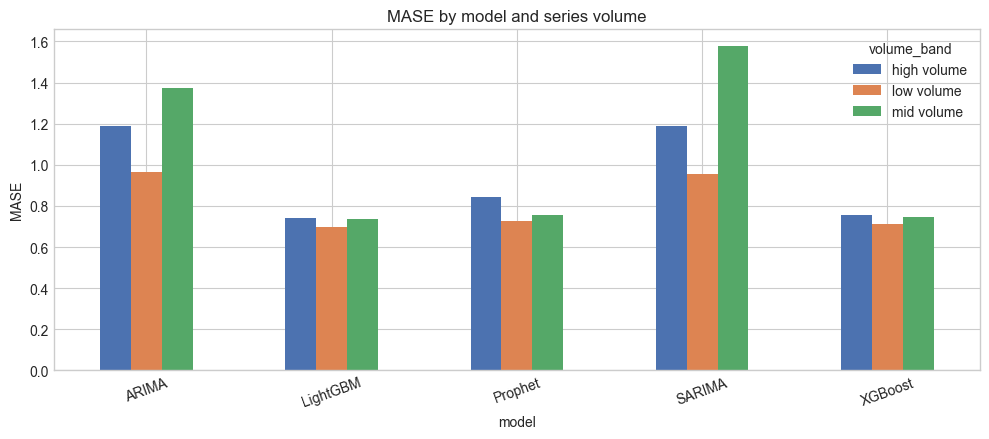

In [170]:
vol = comparison.groupby("store_item")["actual"].mean()
tercile = pd.qcut(vol, 3, labels=["low volume", "mid volume", "high volume"])
comparison["volume_band"] = comparison["store_item"].map(tercile)

seg_rows = []
for band, g in comparison.groupby("volume_band", observed=True):
    for m in models:
        per = [
            mase(gg["actual"].values, gg[f"pred_{m}"].values,
                 train_by_series.get_group(sid).values)
            for sid, gg in g.groupby("store_item")
        ]
        seg_rows.append({"volume_band": band, "model": m, "MASE": np.nanmean(per)})

seg = pd.DataFrame(seg_rows).pivot(index="model", columns="volume_band", values="MASE")
display(seg.round(3))

seg.plot(kind="bar", figsize=(10, 4.5))
plt.title("MASE by model and series volume")
plt.ylabel("MASE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "mase_by_volume_band.png"), dpi=120)
plt.show()

### Forecast plots

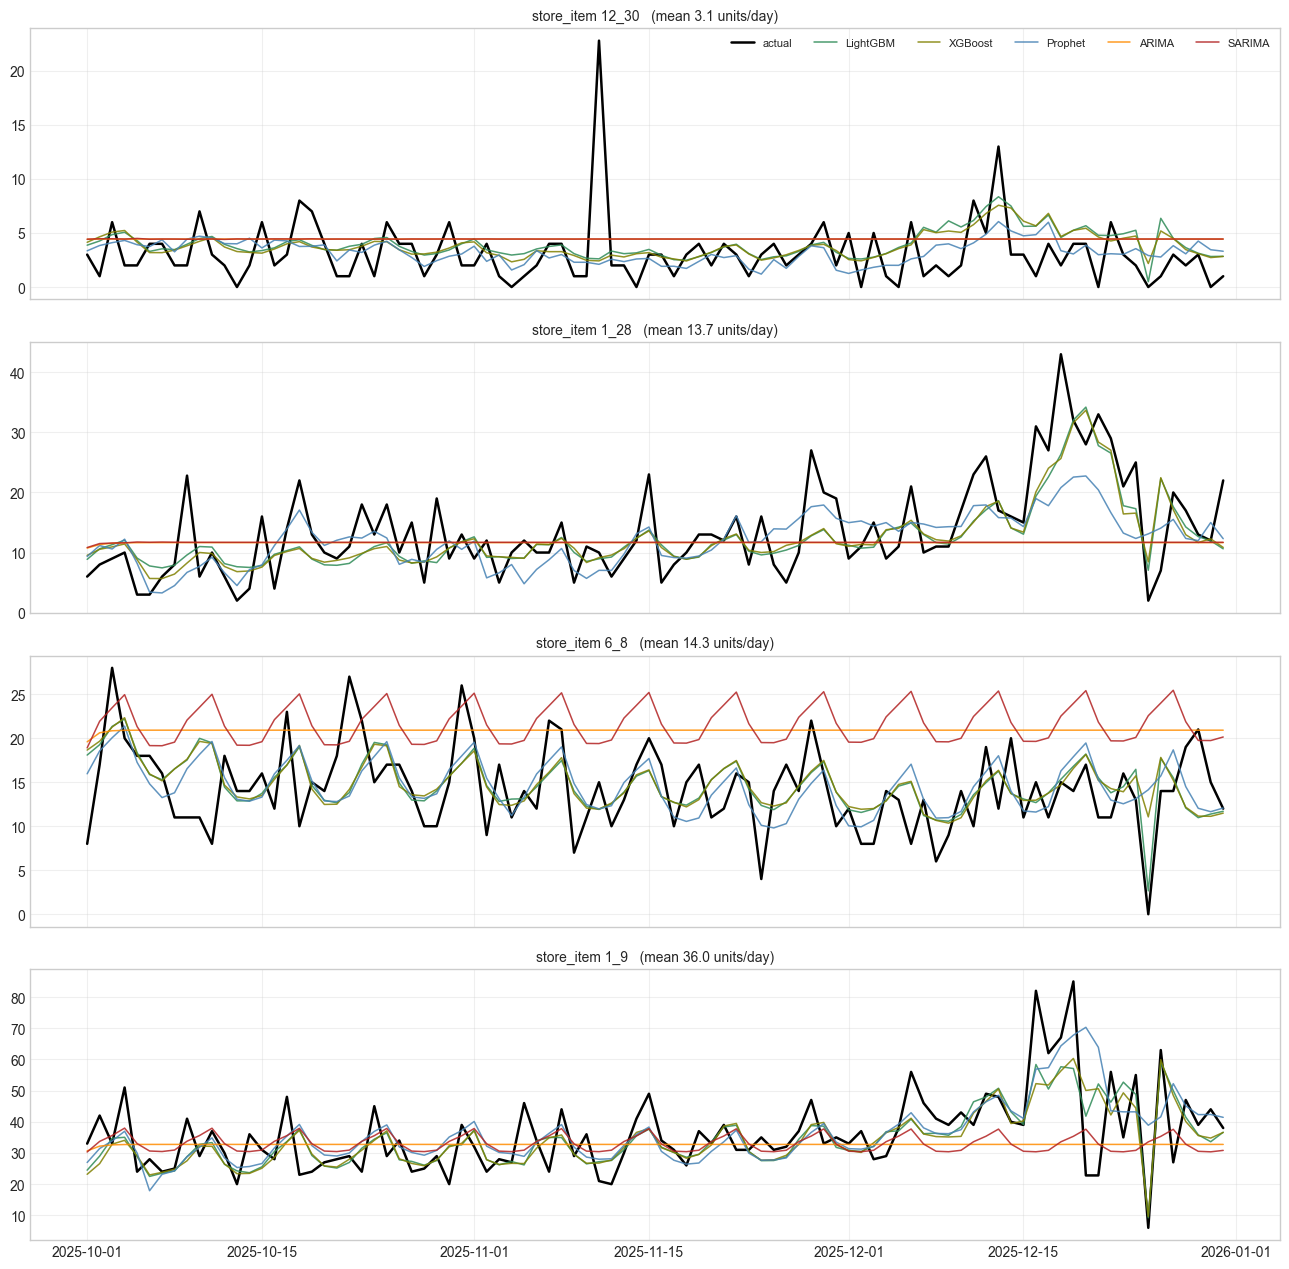

In [171]:
show = local_series[::max(1, len(local_series) // 4)][:4]
fig, axes = plt.subplots(len(show), 1, figsize=(13, 3.2 * len(show)), sharex=True)
axes = np.atleast_1d(axes)

for ax, sid in zip(axes, show):
    g = comparison[comparison["store_item"] == sid].sort_values("date")
    ax.plot(g["date"], g["actual"], color="black", linewidth=1.8, label="actual")
    for m, c in zip(models, ["seagreen", "olive", "steelblue", "darkorange", "firebrick"]):
        ax.plot(g["date"], g[f"pred_{m}"], linewidth=1.1, alpha=0.85, label=m, color=c)
    ax.set_title(f"store_item {sid}   (mean {vol[sid]:.1f} units/day)", fontsize=10)
    ax.grid(alpha=0.3)
axes[0].legend(ncol=6, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "forecast_comparison.png"), dpi=120)
plt.show()

## Feature importance (global models)

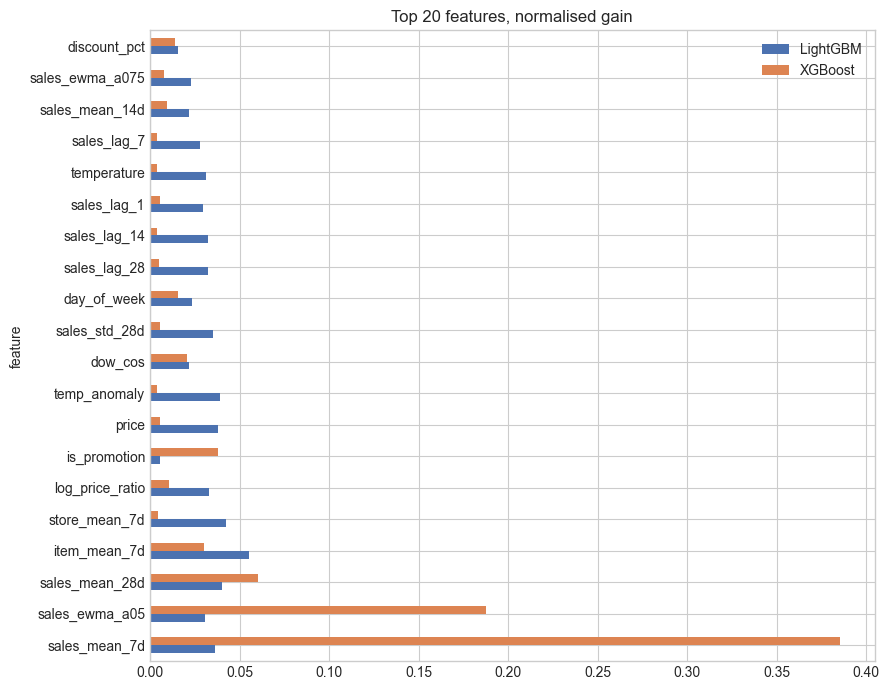

Spearman correlation between the two importance rankings: 0.511
Carry this into Part V: agreement here is the baseline that SHAP must beat.


In [172]:
imp = pd.DataFrame({
    "feature": feature_cols,
    "LightGBM": lgbm_model.feature_importances_ / lgbm_model.feature_importances_.sum(),
    "XGBoost": xgb_model.feature_importances_ / xgb_model.feature_importances_.sum(),
}).set_index("feature")

top = imp.assign(mean=imp.mean(axis=1)).nlargest(20, "mean").drop(columns="mean")
top.plot(kind="barh", figsize=(9, 7))
plt.title("Top 20 features, normalised gain")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "feature_importance.png"), dpi=120)
plt.show()

rho = imp["LightGBM"].corr(imp["XGBoost"], method="spearman")
print(f"Spearman correlation between the two importance rankings: {rho:.3f}")
print("Carry this into Part V: agreement here is the baseline that SHAP must beat.")

## Save trained models

In [173]:
artifacts = {
    "lightgbm": lgbm_model,
    "xgboost": xgb_model,
}
for name, model in artifacts.items():
    path = os.path.join(MODELS_DIR, f"{name}_model.pkl")
    with open(path, "wb") as f:
        pickle.dump(model, f)
    print(f"saved {path}")

metadata = {
    "model_version": "2.0.0",
    "last_trained": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "feature_columns": feature_cols,
    "categorical_features": cat_features,
    "target": TARGET,
    "train_end": str(df_features.loc[train_mask, "date"].max().date()),
    "test_start": str(cutoff.date()),
    "n_local_series": len(local_series),
    "results": results.to_dict("records"),
}
with open(os.path.join(MODELS_DIR, "model_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

comparison.to_csv(os.path.join(DATA_DIR, "model_predictions.csv"), index=False)
results.to_csv(os.path.join(DATA_DIR, "model_results.csv"), index=False)
print("saved metadata and predictions")

saved ../models\lightgbm_model.pkl
saved ../models\xgboost_model.pkl
saved metadata and predictions


## What was changed, and why

| Issue in the original | Fix |
|---|---|
| Optuna used `eval_set=[(X_test, y_test)]` for early stopping - **the number of trees was selected on the test set** | A 28-day validation window carved out of training |
| `feature_engineered_data_55_features.feather` | The 69-feature parquet produced by Part III |
| Prophet aggregation referenced `is_holiday`, which does not exist | `is_public_holiday`, plus school holiday, promotion and weather regressors |
| `plot_forecast_single(..., "Ba Dinh Supermarket_Baby Wipes")` | Series drawn from this dataset |
| `promo_id` left in the feature matrix | Dropped - an arbitrary campaign ID lets the model memorise individual promotions |
| `save_model` hard-coded Vietnamese temperature bins | Metadata written from the actual fitted configuration |
| MAE and RMSE only, dominated by high-volume items | MASE added, and the headline table is ranked on it |
| No test of whether model differences are real | Diebold-Mariano across all ten pairs |
| Two models | Five, with global and local compared on identical series |

### Runtime note

`N_LOCAL_SERIES = 24` keeps a full pass to a few minutes. Set it to `None` for all
360 series before reporting final numbers - the local models are the slow part, and
Prophet dominates that cost.